# Setup

In [1]:

import sys, subprocess

packages = [
    ["synapseclient"],
    ["nibabel", "pandas", "openpyxl", "pillow"],
    ["torch", "torchvision", "matplotlib"],
]
for pkgs in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *pkgs])


In [ ]:
from pathlib import Path

# -----------------------
# PATH CONFIG
# -----------------------
TOKEN = ""  #Synapse Personal Access Token (PAT)
ZIP_PATH = "./ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData.zip"
MAPPING_XLSX = "./BraTS2023_2017_GLI_Mapping.xlsx"
OUT_ROOT = "./brats23_npz_dg"
INDEX_CSV = "./brats23_npz_dg/index.csv"

# BraTS modalities you saw: t1c, t1n, t2w, t2f
# t2f ~ FLAIR is a good default for tumor visibility
MODALITY = "t2f"

# Slicing & selection
AXIS = 2  # axial
MIN_BRAIN_PIXELS = 500
TUMOR_PIXEL_THRESHOLD = 20

# KEEP FEWER SLICES (controls dataset size!)
VALIDATION_FRACTION = 0.15
IN_DOMAIN_TEST_FRACTION = 0.15
MAX_TUMOR_SLICES = 40
MAX_NORMAL_SLICES = 40
MAX_CASES_PER_SITE = 64  # cap seen-domain cases per site before split to prevent bias toward large sites
MIN_CASES_FOR_LOSO = 30  # only rank held-out sites with enough cases for a leave-one-site-out (LOSO) evaluation
OUT_SIZE = (224, 224) # Save slices as 224x224 uint8 inside NPZ

# Training config
EXP_SEED = 18662 # Seed for reproducibility
EARLY_STOP_PATIENCE = 3



# Dataset

**Backup**
- [OASIS](https://arc.net/l/quote/rwsqdjgl) dataset for training and in-domain test
- [alzheimers-dataset-4-class-of-images](https://www.kaggle.com/datasets/preetpalsingh25/alzheimers-dataset-4-class-of-images) for testing and out-domain test
- [ANDI](https://adni.loni.usc.edu/data-samples/adni-data/) dataset (permission required)

**Current**
- [BraTS](https://www.synapse.org/Synapse:syn51514105), dataset containing brain tumor scan from diff hospitals. can be separated into subsets by hospital then used for domain shift test.

**Download Instruction**

    1. Register and request dataset permission
    2. Create Synapse token for Programmatic Download
    3. Replace the token with your own token to download.

In [3]:
import os
from pathlib import Path
import synapseclient

ZIP_PATH = str(Path(ZIP_PATH).expanduser())
if not Path(ZIP_PATH).exists():
    print(f"Dataset zip missing, downloading from Synapse...")
    syn = synapseclient.Synapse()
    syn.login(authToken=TOKEN)
    syn51514132 = syn.get(entity="syn51514132", downloadLocation="./")
    ZIP_PATH = syn51514132.path
else:
    print(f"Using local ZIP_PATH: {ZIP_PATH}")


Using local ZIP_PATH: ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData.zip


## 1. Preprocess ZIP → compact NPZ dataset on Drive
1. Reads BraTS 2023 GLI TrainingData ZIP

2. Uses mapping .xlsx to assign site (hospital domain)

3. Converts 3D → 2D axial slices

4. Labels each slice as tumor / normal using *-seg.nii.gz

5. Keeps only a limited number of slices per case (so size stays small)

6. Saves one compressed .npz per case, organized by site_xx/

7. Includes a PyTorch Dataset that loads .npz and returns tensors for ResNet-18 / MixStyle

The resulted dataset

- ./brats23_npz_dg/
  - site_01/BraTS-GLI-xxxxx-000.npz
  - site_02/...
  - index.csv

Each .npz contains images (N,224,224) and labels (N,)

In [4]:
import re, zipfile, tempfile
from pathlib import Path
import numpy as np
import pandas as pd
import nibabel as nib
from PIL import Image

# -----------------------
# Helpers
# -----------------------
def parse_case_id(path_in_zip: str) -> str | None:
    m = re.search(r"(BraTS-GLI-\d{5}-\d{3})", path_in_zip)
    return m.group(1) if m else None

def load_nii_from_zip(z: zipfile.ZipFile, member: str) -> np.ndarray:
    """Read .nii.gz bytes from zip -> temp file -> nibabel -> numpy array."""
    data = z.read(member)
    # with tempfile.NamedTemporaryFile(suffix=".nii.gz", delete=True) as tmp:
    #     tmp.write(data)
    #     tmp.flush()
    #     return nib.load(tmp.name).get_fdata().astype(np.float32)
    fd, tmp_path = tempfile.mkstemp(suffix=".nii.gz")
    os.close(fd)
    try:
        with open(tmp_path, "wb") as f:
            f.write(data)
        return nib.load(tmp_path).get_fdata().astype(np.float32)
    finally:
        if os.path.exists(tmp_path):
            os.remove(tmp_path)

def zscore_nonzero(vol: np.ndarray, eps: float = 1e-6) -> np.ndarray:
    mask = vol != 0
    if mask.sum() < 100:
        return (vol - vol.mean()) / (vol.std() + eps)
    vals = vol[mask]
    mu, sigma = vals.mean(), vals.std() + eps
    out = vol.copy()
    out[mask] = (out[mask] - mu) / sigma
    out[~mask] = 0.0
    return out

def slice_to_uint8(img2d: np.ndarray) -> np.ndarray:
    """Robust percentile scaling to uint8."""
    x = img2d.astype(np.float32)
    nz = x[x != 0]
    if nz.size < 10:
        return np.zeros_like(x, dtype=np.uint8)
    lo, hi = np.percentile(nz, [1, 99])
    if (hi - lo) < 1e-6:
        return np.zeros_like(x, dtype=np.uint8)
    x = np.clip(x, lo, hi)
    x = (x - lo) / (hi - lo)
    return (x * 255.0).astype(np.uint8)

def resize_uint8(img_u8: np.ndarray, out_hw=(224,224)) -> np.ndarray:
    pil = Image.fromarray(img_u8, mode="L")
    pil = pil.resize(out_hw, resample=Image.BILINEAR)
    return np.array(pil, dtype=np.uint8)

def choose_evenly(indices: list[int], max_keep: int) -> list[int]:
    """Evenly subsample a list to length max_keep (deterministic)."""
    if len(indices) <= max_keep:
        return indices
    idxs = np.linspace(0, len(indices) - 1, num=max_keep).astype(int)
    return [indices[i] for i in idxs]

# Output NPZ root on Drive (reusable later)
out_dir = Path(OUT_ROOT)
out_dir.mkdir(parents=True, exist_ok=True)

# Skip unzip if already unziped
if any(out_dir.iterdir()):
    print(f"OUT_ROOT already exists, skipping unzip/processing: {out_dir}")
else:
    # -----------------------
    # Load mapping: case -> site
    # -----------------------
    df_map = pd.read_excel(MAPPING_XLSX)
    CASE_COL = "BraTS2023"
    SITE_COL = "Site No (represents the originating institution)"
    df_map = df_map[[CASE_COL, SITE_COL]].dropna()
    df_map[SITE_COL] = df_map[SITE_COL].astype(int)
    case_to_site = dict(zip(df_map[CASE_COL].astype(str), df_map[SITE_COL]))

    print("Mapping entries:", len(case_to_site))

    # -----------------------
    # Process ZIP -> per-case NPZ
    # -----------------------
    index_rows = []
    skipped_no_site = 0
    skipped_missing = 0

    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        names = z.namelist()

        # group members by case_id
        case_members = {}
        for n in names:
            cid = parse_case_id(n)
            if cid:
                case_members.setdefault(cid, []).append(n)

        print("Cases in zip:", len(case_members))

        for k, (case_id, members) in enumerate(case_members.items(), start=1):
            site = case_to_site.get(case_id, None)
            if site is None:
                skipped_no_site += 1
                continue

            # find paths
            img_path = next((m for m in members if m.endswith(f"-{MODALITY}.nii.gz")), None)
            seg_path = next((m for m in members if m.endswith("-seg.nii.gz")), None)

            if img_path is None or seg_path is None:
                skipped_missing += 1
                continue

            img_vol = zscore_nonzero(load_nii_from_zip(z, img_path))
            seg_vol = load_nii_from_zip(z, seg_path)
            if img_vol.shape != seg_vol.shape:
                skipped_missing += 1
                continue

            D = img_vol.shape[AXIS]

            tumor_idxs, normal_idxs = [], []
            for s in range(D):
                img_slice = img_vol[:, :, s]
                seg_slice = seg_vol[:, :, s]

                # skip near-empty slices
                if (img_slice != 0).sum() < MIN_BRAIN_PIXELS:
                    continue

                tumor_pixels = int((seg_slice > 0).sum())
                if tumor_pixels >= TUMOR_PIXEL_THRESHOLD:
                    tumor_idxs.append(s)
                else:
                    normal_idxs.append(s)

            # Keep fewer slices (controls size)
            tumor_keep = choose_evenly(tumor_idxs, MAX_TUMOR_SLICES)
            normal_keep = choose_evenly(normal_idxs, MAX_NORMAL_SLICES)

            # Build arrays
            slices = []
            labels = []

            for s in tumor_keep:
                u8 = resize_uint8(slice_to_uint8(img_vol[:, :, s]), OUT_SIZE)
                slices.append(u8)
                labels.append(1)

            for s in normal_keep:
                u8 = resize_uint8(slice_to_uint8(img_vol[:, :, s]), OUT_SIZE)
                slices.append(u8)
                labels.append(0)

            if len(slices) == 0:
                continue

            x = np.stack(slices, axis=0).astype(np.uint8)   # [N,224,224]
            y = np.array(labels, dtype=np.uint8)            # [N]

            # Save per case
            site_dir = out_dir / f"site_{site:02d}"
            site_dir.mkdir(parents=True, exist_ok=True)

            out_npz = site_dir / f"{case_id}.npz"
            np.savez_compressed(
                out_npz,
                images=x,
                labels=y,
                case_id=np.array(case_id),
                site=np.array(site, dtype=np.int32),
                modality=np.array(MODALITY),
            )

            index_rows.append({
                "case_id": case_id,
                "site": site,
                "npz_path": str(out_npz),
                "num_slices": int(x.shape[0]),
                "num_tumor": int((y == 1).sum()),
                "num_normal": int((y == 0).sum()),
            })

            if k % 50 == 0:
                print(f"Processed {k}/{len(case_members)} cases...")

    # Save index CSV
    index_df = pd.DataFrame(index_rows).sort_values(["site", "case_id"])
    index_csv = out_dir / "index.csv"
    index_df.to_csv(index_csv, index=False)

    print("Done.")
    print("Saved NPZ dataset to:", out_dir)
    print("Index:", index_csv)
    print("Skipped (no site):", skipped_no_site)
    print("Skipped (missing files/shape):", skipped_missing)

    print("Example rows:")
    display(index_df.head())
    print("Total cases saved:", len(index_df))
    print("Total slices saved:", int(index_df["num_slices"].sum()))


Mapping entries: 1251
Cases in zip: 1251
Processed 50/1251 cases...
Processed 100/1251 cases...
Processed 150/1251 cases...
Processed 200/1251 cases...
Processed 250/1251 cases...
Processed 300/1251 cases...
Processed 350/1251 cases...
Processed 400/1251 cases...
Processed 450/1251 cases...
Processed 500/1251 cases...
Processed 550/1251 cases...
Processed 600/1251 cases...
Processed 650/1251 cases...
Processed 700/1251 cases...
Processed 750/1251 cases...
Processed 800/1251 cases...
Processed 850/1251 cases...
Processed 900/1251 cases...
Processed 950/1251 cases...
Processed 1000/1251 cases...
Processed 1050/1251 cases...
Processed 1100/1251 cases...
Processed 1150/1251 cases...
Processed 1200/1251 cases...
Processed 1250/1251 cases...
Done.
Saved NPZ dataset to: brats23_npz_dg
Index: brats23_npz_dg\index.csv
Skipped (no site): 0
Skipped (missing files/shape): 0
Example rows:


,case_id,site,npz_path,num_slices,num_tumor,num_normal
1012,BraTS-GLI-00131-000,1,brats23_npz_dg\site_01\BraTS-GLI-00131-000.npz,80,40,40
1082,BraTS-GLI-00152-000,1,brats23_npz_dg\site_01\BraTS-GLI-00152-000.npz,80,40,40
460,BraTS-GLI-00154-000,1,brats23_npz_dg\site_01\BraTS-GLI-00154-000.npz,80,40,40
503,BraTS-GLI-00155-000,1,brats23_npz_dg\site_01\BraTS-GLI-00155-000.npz,80,40,40
436,BraTS-GLI-00156-000,1,brats23_npz_dg\site_01\BraTS-GLI-00156-000.npz,80,40,40


Total cases saved: 1251
Total slices saved: 99199


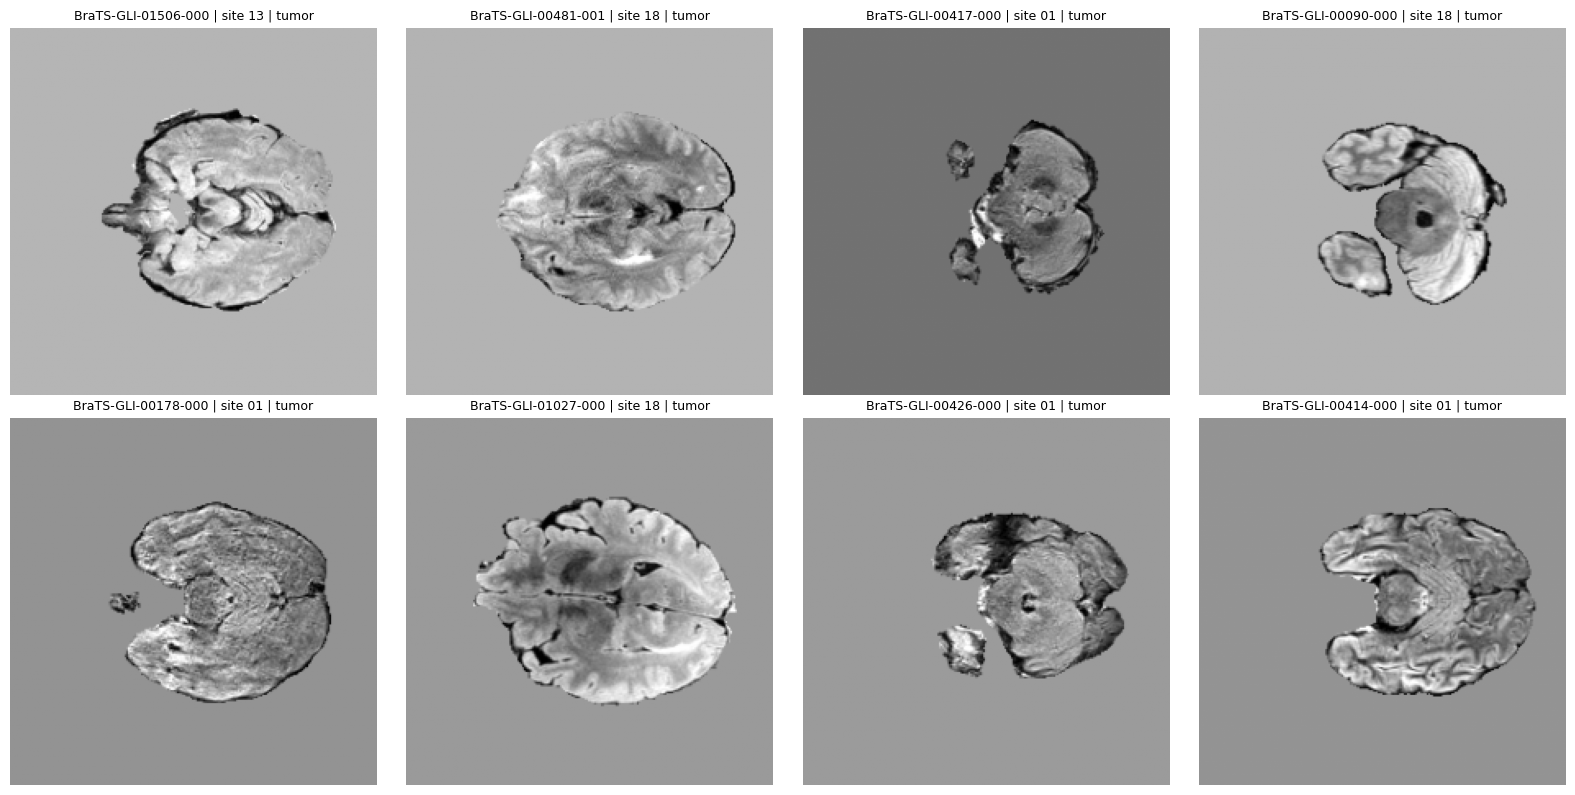

In [6]:
import matplotlib.pyplot as plt
from pathlib import Path

assert Path(INDEX_CSV).exists(), f"index.csv not found at: {INDEX_CSV}"

# How many images to show
N_SHOW = 8

# Pick mode: "random" or "first"
MODE = "random"

df = pd.read_csv(INDEX_CSV)

# Filter to cases that exist and have at least 1 slice
df = df[df["num_slices"] > 0].copy()

# Sample cases
if MODE == "random":
    df_s = df.sample(n=min(N_SHOW, len(df)), random_state=0)
else:
    df_s = df.head(N_SHOW)

# Plot one slice per case (pick a tumor slice if available, else any)
plt.figure(figsize=(16, 8))
for i, row in enumerate(df_s.itertuples(index=False), start=1):
    npz_path = Path(row.npz_path)
    assert npz_path.exists(), f"Missing npz: {npz_path}"
    data = np.load(npz_path, allow_pickle=True)
    imgs = data["images"]         # [N,224,224] uint8
    labels = data["labels"]       # [N] 0/1

    # Choose a slice to display: prefer tumor slice if present
    tumor_idx = np.where(labels == 1)[0]
    if len(tumor_idx) > 0:
        j = int(tumor_idx[0])
        title = f"{row.case_id} | site {row.site:02d} | tumor"
    else:
        j = 0
        title = f"{row.case_id} | site {row.site:02d} | normal"

    img = imgs[j]

    ax = plt.subplot(2, (N_SHOW + 1)//2, i)
    ax.imshow(img, cmap="gray")
    ax.set_title(title, fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 2. PyTorch Dataset: load NPZ and feed into ResNet-18

In [7]:
import glob
import numpy as np
import os
import random
import numpy as np
import torch
from torch.utils.data import Dataset

class BraTSNPZSliceDataset(Dataset):
    """
    Loads per-case .npz files and exposes slice-level samples.
    Caches all arrays in memory to reduce disk I/O.
    Returns:
      x: FloatTensor [3,224,224] in [0,1]
      y: LongTensor scalar (0/1)
      site: int (domain id)
      case_id: str
    """
    def __init__(self, npz_paths):
        self.npz_paths = list(npz_paths)

        self._files = []
        self._index = []
        for fi, p in enumerate(self.npz_paths):
            with np.load(p) as d:
                images = d["images"].astype(np.uint8, copy=False)
                labels = d["labels"].astype(np.int64, copy=False)
                site = int(d["site"])
                case_id = str(d["case_id"])
            self._files.append({
                "images": images,
                "labels": labels,
                "site": site,
                "case_id": case_id,
            })
            self._index.extend([(fi, si) for si in range(images.shape[0])])

    def __len__(self):
        return len(self._index)

    def __getitem__(self, idx):
        fi, si = self._index[idx]
        f = self._files[fi]
        img = f["images"][si]  # [224,224] uint8
        y = int(f["labels"][si])

        x = torch.from_numpy(img).float().unsqueeze(0) / 255.0
        x = x.repeat(3, 1, 1)
        y = torch.tensor(y, dtype=torch.long)
        return x, y, f["site"], f["case_id"]

## 3. Create DG train/val/test by hospital (site)

In [20]:
# Split seen-domain cases into train/val/in-domain test
def split_seen_cases_by_site(case_df, val_fraction, test_fraction, seed):
    train_case_ids, val_case_ids, test_case_ids = [], [], []
    for site, site_cases in case_df.groupby("site"):
        case_ids = site_cases["case_id"].drop_duplicates().to_numpy().copy()
        rng = np.random.default_rng(seed + int(site))
        rng.shuffle(case_ids)

        n_cases = len(case_ids)
        n_val = int(round(n_cases * val_fraction))
        n_test = int(round(n_cases * test_fraction))
        if n_cases >= 3:
            if n_val == 0:
                n_val = 1
            if n_test == 0:
                n_test = 1
            while n_val + n_test >= n_cases:
                if n_test >= n_val and n_test > 1:
                    n_test -= 1
                elif n_val > 1:
                    n_val -= 1
                else:
                    break
        elif n_cases == 2:
            n_val, n_test = 1, 0
        else:
            n_val, n_test = 0, 0

        val_case_ids.extend(case_ids[:n_val].tolist())
        test_case_ids.extend(case_ids[n_val:n_val + n_test].tolist())
        train_case_ids.extend(case_ids[n_val + n_test:].tolist())

    return set(train_case_ids), set(val_case_ids), set(test_case_ids)

# Summarize splits (overall + top sites)
def summarize_split(name, df):
    case_count = df["case_id"].nunique()
    slice_count = int(df["num_slices"].sum())
    tumor_count = int(df["num_tumor"].sum())
    normal_count = int(df["num_normal"].sum())
    total_labeled = tumor_count + normal_count
    tumor_ratio = (tumor_count / total_labeled) if total_labeled else 0.0
    print(f"\n{name}")
    print(f"cases={case_count}, slices={slice_count}, tumor={tumor_count}, normal={normal_count}, tumor_ratio={tumor_ratio:.4f}")
    print("top sites by cases:")
    print(df.groupby("site")["case_id"].nunique().sort_values(ascending=False).head(10))


# Create LOSO splits for a given held-out site
def make_loso_split(index_df, held_out_site, val_fraction=VALIDATION_FRACTION, test_fraction=IN_DOMAIN_TEST_FRACTION, max_cases_per_site=MAX_CASES_PER_SITE, seed=EXP_SEED):
    seen_df = index_df[index_df["site"] != held_out_site].copy()
    held_out_df = index_df[index_df["site"] == held_out_site].copy()

    seen_cases = seen_df[["site", "case_id"]].drop_duplicates()
    seen_cases = pd.concat(
        [
            site_cases.sample(n=min(len(site_cases), max_cases_per_site), random_state=seed)
            for _, site_cases in seen_cases.groupby("site")
        ],
        ignore_index=True,
    )

    selected_case_ids = set(seen_cases["case_id"].tolist())
    selected_seen_df = seen_df[seen_df["case_id"].isin(selected_case_ids)].copy()
    train_case_ids, val_case_ids, in_domain_case_ids = split_seen_cases_by_site(seen_cases, val_fraction, test_fraction, seed)

    split_frames = {
        "train_df": selected_seen_df[selected_seen_df["case_id"].isin(train_case_ids)].copy(),
        "val_df": selected_seen_df[selected_seen_df["case_id"].isin(val_case_ids)].copy(),
        "in_domain_test_df": selected_seen_df[selected_seen_df["case_id"].isin(in_domain_case_ids)].copy(),
        "out_domain_test_df": held_out_df.copy(),
    }
    return split_frames


In [21]:
from pathlib import Path
import pandas as pd
from torch.utils.data import DataLoader

DATA_ROOT = Path("./brats23_npz_dg/")
index_df = pd.read_csv(DATA_ROOT / "index.csv")

# inspect which sites are large enough
print("\n=== Sites Overview ===")
print(index_df.groupby("site")["case_id"].count().sort_values(ascending=False).head(10))

site_domain_summary = (
    index_df.groupby("site")
    .agg(
        cases=("case_id", "nunique"),
        slices=("num_slices", "sum"),
        tumor=("num_tumor", "sum"),
        normal=("num_normal", "sum"),
    )
    .reset_index()
)
site_domain_summary["tumor_ratio"] = site_domain_summary["tumor"] / (site_domain_summary["tumor"] + site_domain_summary["normal"])
site_domain_summary["candidate_for_loso"] = site_domain_summary["cases"] >= MIN_CASES_FOR_LOSO
candidate_sites_for_loso = site_domain_summary.loc[site_domain_summary["candidate_for_loso"], "site"].tolist()

print("\n=== Dataset Diagnostics ===")
display(site_domain_summary.sort_values(["candidate_for_loso", "cases"], ascending=[False, False]))
print("Candidate held-out sites for leave-one-site-out:", candidate_sites_for_loso)

# Build a table summarizing how many cases per site
def build_loso_site_case_table(index_df, min_cases=MIN_CASES_FOR_LOSO):
    case_table = (
        index_df[["site", "case_id"]]
        .drop_duplicates()
        .groupby("site")
        .size()
        .rename("cases")
        .reset_index()
    )
    case_table["candidate_for_loso"] = case_table["cases"] >= min_cases
    return case_table.sort_values(["candidate_for_loso", "cases"], ascending=[False, False]).reset_index(drop=True)

loso_site_case_table = build_loso_site_case_table(index_df)
display(loso_site_case_table)



=== Sites Overview ===
site
1     511
18    382
4      47
13     35
21     35
6      34
20     33
16     30
5      22
3      15
Name: case_id, dtype: int64

=== Dataset Diagnostics ===


,site,cases,slices,tumor,normal,tumor_ratio,candidate_for_loso
0,1,511,40465,20069,20396,0.495959,True
17,18,382,30232,14980,15252,0.495501,True
3,4,47,3733,1874,1859,0.502009,True
12,13,35,2795,1395,1400,0.499106,True
20,21,35,2785,1388,1397,0.498384,True
5,6,34,2713,1353,1360,0.498710,True
19,20,33,2640,1320,1320,0.500000,True
15,16,30,2387,1187,1200,0.497277,True
4,5,22,1748,869,879,0.497140,False
2,3,15,1171,576,595,0.491887,False


Candidate held-out sites for leave-one-site-out: [1, 4, 6, 13, 16, 18, 20, 21]


,site,cases,candidate_for_loso
0,1,511,True
1,18,382,True
2,4,47,True
3,13,35,True
4,21,35,True
5,6,34,True
6,20,33,True
7,16,30,True
8,5,22,False
9,3,15,False


# Model

We will be testing existing model $MixStyle$ from the following paper [Domain Generalization with MixStyle](https://arxiv.org/abs/2104.02008)

Domain generalization: train on dataset A, in-domian test on dataset A split, out-domain-test on dataset B. It tries to learn features that are invariant across domains, meaning the model focuses on disease patterns instead of dataset-specific characteristics.

In [34]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from tqdm import tqdm
def set_seed(seed: int = 42):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(EXP_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_amp = (device.type == "cuda")
scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
print(device)

cuda


## MixStyle Module

In [27]:
import random

class MixStyle(nn.Module):
    """MixStyle.
    Reference:
      Zhou et al. Domain Generalization with MixStyle. ICLR 2021.
    """

    def __init__(self, p=0.5, alpha=0.1, eps=1e-6, mix='random'):
        """
        Args:
          p (float): probability of using MixStyle.
          alpha (float): parameter of the Beta distribution.
          eps (float): scaling parameter to avoid numerical issues.
          mix (str): how to mix.
        """
        super().__init__()
        self.p = p
        self.beta = torch.distributions.Beta(alpha, alpha)
        self.eps = eps
        self.alpha = alpha
        self.mix = mix
        self._activated = True

    def __repr__(self):
        return f'MixStyle(p={self.p}, alpha={self.alpha}, eps={self.eps}, mix={self.mix})'

    def set_activation_status(self, status=True):
        self._activated = status

    def update_mix_method(self, mix='random'):
        self.mix = mix

    def forward(self, x):
        if not self.training or not self._activated:
            return x

        if random.random() > self.p:
            return x

        B = x.size(0)

        mu = x.mean(dim=[2, 3], keepdim=True)
        var = x.var(dim=[2, 3], keepdim=True)
        sig = (var + self.eps).sqrt()
        mu, sig = mu.detach(), sig.detach()
        x_normed = (x-mu) / sig

        lmda = self.beta.sample((B, 1, 1, 1))
        lmda = lmda.to(x.device)

        if self.mix == 'random':
            # random shuffle
            perm = torch.randperm(B)

        elif self.mix == 'crossdomain':
            # split into two halves and swap the order
            perm = torch.arange(B - 1, -1, -1) # inverse index
            perm_b, perm_a = perm.chunk(2)
            perm_b = perm_b[torch.randperm(B // 2)]
            perm_a = perm_a[torch.randperm(B // 2)]
            perm = torch.cat([perm_b, perm_a], 0)

        else:
            raise NotImplementedError

        mu2, sig2 = mu[perm], sig[perm]
        mu_mix = mu*lmda + mu2 * (1-lmda)
        sig_mix = sig*lmda + sig2 * (1-lmda)

        return x_normed*sig_mix + mu_mix

## ResNet with MixStyle

In [29]:
class ResNet18MixStyle(nn.Module):
    def __init__(
        self,
        num_classes=2,
        pretrained=True,
        mixstyle_p=0.5,
        mixstyle_alpha=0.1,
        insert_after=("layer1", "layer2"),
    ):
        super().__init__()
        self.backbone = models.resnet18(pretrained=pretrained)

        # Replace classifier
        in_feats = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(in_feats, num_classes)

        # MixStyle modules
        self.ms1 = MixStyle(p=mixstyle_p, alpha=mixstyle_alpha) if "layer1" in insert_after else None
        self.ms2 = MixStyle(p=mixstyle_p, alpha=mixstyle_alpha) if "layer2" in insert_after else None
        self.ms3 = MixStyle(p=mixstyle_p, alpha=mixstyle_alpha) if "layer3" in insert_after else None
        self.ms4 = MixStyle(p=mixstyle_p, alpha=mixstyle_alpha) if "layer4" in insert_after else None

    def forward(self, x):
        x = self.backbone.conv1(x)
        x = self.backbone.bn1(x)
        x = self.backbone.relu(x)
        x = self.backbone.maxpool(x)

        x = self.backbone.layer1(x)
        if self.ms1 is not None:
            x = self.ms1(x)

        x = self.backbone.layer2(x)
        if self.ms2 is not None:
            x = self.ms2(x)

        x = self.backbone.layer3(x)
        if self.ms3 is not None:
            x = self.ms3(x)

        x = self.backbone.layer4(x)
        if self.ms4 is not None:
            x = self.ms4(x)

        x = self.backbone.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.backbone.fc(x)
        return x


## Training function

In [30]:
def train_epoch(model, loader, optimizer, criterion):

    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for x, y, site, case_id in tqdm(loader):

        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(device_type=device.type, enabled=use_amp):
            out = model(x)
            loss = criterion(out, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

        preds = out.argmax(dim=1)

        correct += (preds == y).sum().item()
        total += y.size(0)

    acc = correct / total

    return total_loss / len(loader), acc


## Testing & validation function

In [31]:
def eval_epoch(model, loader):

    model.eval()

    correct = 0
    total = 0

    with torch.inference_mode():

        for x, y, site, case_id in loader:

            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            with torch.autocast(device_type=device.type, enabled=use_amp):
                out = model(x)

            preds = out.argmax(dim=1)

            correct += (preds == y).sum().item()
            total += y.size(0)

    acc = correct / total

    return acc

def eval_metrics(model, loader):
    model.eval()

    tp = fp = tn = fn = 0

    with torch.inference_mode():
        for x, y, site, case_id in loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            with torch.autocast(device_type=device.type, enabled=use_amp):
                out = model(x)

            preds = out.argmax(dim=1)

            tp += ((preds == 1) & (y == 1)).sum().item()
            fp += ((preds == 1) & (y == 0)).sum().item()
            tn += ((preds == 0) & (y == 0)).sum().item()
            fn += ((preds == 0) & (y == 1)).sum().item()

    total = tp + fp + tn + fn
    accuracy = (tp + tn) / total if total else 0.0
    recall_tumor = tp / (tp + fn) if (tp + fn) else 0.0
    recall_normal = tn / (tn + fp) if (tn + fp) else 0.0
    balanced_accuracy = 0.5 * (recall_tumor + recall_normal)
    precision_tumor = tp / (tp + fp) if (tp + fp) else 0.0
    f1_tumor = (2 * precision_tumor * recall_tumor / (precision_tumor + recall_tumor)) if (precision_tumor + recall_tumor) else 0.0

    return {
        "accuracy": accuracy,
        "balanced_accuracy": balanced_accuracy,
        "tumor_precision": precision_tumor,
        "tumor_recall": recall_tumor,
        "tumor_f1": f1_tumor,
        "tp": tp,
        "fp": fp,
        "tn": tn,
        "fn": fn,
    }

# Experiment

Helper class and functions

In [50]:
from dataclasses import dataclass
from typing import FrozenSet

@dataclass(frozen=True)
class DataSplitConfig:
    name: str
    train_cases: FrozenSet[str]
    validation_cases: FrozenSet[str]
    test_cases: FrozenSet[str]
    out_domain_test_cases: FrozenSet[str] = frozenset()

    def prepare_dataloaders(self, index_df, batch_size=128):
        train_df = index_df[index_df["case_id"].isin(self.train_cases)].copy()
        val_df = index_df[index_df["case_id"].isin(self.validation_cases)].copy()
        test_df = index_df[index_df["case_id"].isin(self.test_cases)].copy()
        out_domain_test_df = index_df[index_df["case_id"].isin(self.out_domain_test_cases)].copy()

        train_ds = BraTSNPZSliceDataset(train_df["npz_path"].tolist())
        val_ds = BraTSNPZSliceDataset(val_df["npz_path"].tolist())
        test_ds = BraTSNPZSliceDataset(test_df["npz_path"].tolist())
        out_domain_test_ds = BraTSNPZSliceDataset(out_domain_test_df["npz_path"].tolist())

        return {
            "train_df": train_df,
            "val_df": val_df,
            "test_df": test_df,
            "out_domain_test_df": out_domain_test_df,
            "train_loader": DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True, persistent_workers=False),
            "val_loader": DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True, persistent_workers=False),
            "test_loader": DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True, persistent_workers=False),
            "out_domain_test_loader": DataLoader(out_domain_test_ds, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True, persistent_workers=False),
        }

def prepare_dataloaders_from_config(data_cfg, index_df, batch_size=128, verbose=True):
    loaders = data_cfg.prepare_dataloaders(index_df=index_df, batch_size=batch_size)
    if verbose:
        print(f"\nData Config: {data_cfg.name}")
        print(f"  train cases={loaders['train_df']['case_id'].nunique()} slices={int(loaders['train_df']['num_slices'].sum())}")
        print(f"  val cases={loaders['val_df']['case_id'].nunique()} slices={int(loaders['val_df']['num_slices'].sum())}")
        print(f"  test cases={loaders['test_df']['case_id'].nunique()} slices={int(loaders['test_df']['num_slices'].sum())}")
        print(f"  out-domain cases={loaders['out_domain_test_df']['case_id'].nunique()} slices={int(loaders['out_domain_test_df']['num_slices'].sum())}")
        print(f"  train sites={sorted(loaders['train_df']['site'].unique().tolist())}")
        print(f"  val sites={sorted(loaders['val_df']['site'].unique().tolist())}")
        print(f"  test sites={sorted(loaders['test_df']['site'].unique().tolist())}")
        print(f"  out-domain sites={sorted(loaders['out_domain_test_df']['site'].unique().tolist())}")
    return loaders

@dataclass(frozen=True)
class ModelConfig:
    name: str
    train_layers: tuple[int, ...] = tuple()
    use_mixstyle: bool = False
    mixstyle_p: float = 0.5
    mixstyle_a: float = 0.1

def build_model(cfg: ModelConfig, pretrained=True, verbose=True):
    insert_after = tuple(f"layer{layer}" for layer in cfg.train_layers) if cfg.use_mixstyle else tuple()
    mixstyle_p = cfg.mixstyle_p
    mixstyle_a = cfg.mixstyle_a
    model = ResNet18MixStyle(
        num_classes=2,
        pretrained=pretrained,
        mixstyle_p=mixstyle_p,
        mixstyle_alpha=mixstyle_a,
        insert_after=insert_after,
    ).to(device)

    # Freeze all then unfreeze the chosen layer
    for p in model.parameters():
        p.requires_grad = False
    for layer in cfg.train_layers:
        getattr(model.backbone, f"layer{layer}").requires_grad_(True)
    model.backbone.fc.requires_grad_(True)

    if verbose:
        trainable_names = [name for name, p in model.named_parameters() if p.requires_grad]
        trainable_count = sum(p.numel() for p in model.parameters() if p.requires_grad)
        layer_label = list(cfg.train_layers) if len(cfg.train_layers) > 0 else ["fc-only"]
        print(f"\nModel Config: {cfg.name}")
        print(f"  train_layers={layer_label}")
        print(f"  use_mixstyle={cfg.use_mixstyle} mixstyle_p={cfg.mixstyle_p} mixstyle_a={cfg.mixstyle_a}")
        print(f"  insert_after={insert_after}")
        print(f"  trainable_params={trainable_count}")
        print(f"  trainable_modules={trainable_names[:12]}{' ...' if len(trainable_names) > 12 else ''}")

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam([p for p in model.parameters() if p.requires_grad], lr=1e-4)
    return model, optimizer, criterion

## LOSO Evaluation

Do a leave-one-site-out evaluation across all candidate sites with enough cases, to see which sites are easier/harder to generalize to.

We can also use the results as baseline model with only fc trained, and compare the in-domain and out-domain test results.

In [ ]:
loso_cfg = ModelConfig(name="LOSO-FC-Only", train_layers=tuple(), use_mixstyle=False)
LOSO_EPOCHS = 5
LOSO_PATIENCE = 3

loso_sites = candidate_sites_for_loso.copy()

def run_loso_experiment(cfg, held_out_site, epochs=LOSO_EPOCHS, patience=LOSO_PATIENCE):
    split_frames = make_loso_split(index_df, held_out_site=held_out_site)
    data_cfg = DataSplitConfig(
        name=f"loso-site-{held_out_site:02d}",
        train_cases=frozenset(split_frames["train_df"]["case_id"].unique().tolist()),
        validation_cases=frozenset(split_frames["val_df"]["case_id"].unique().tolist()),
        test_cases=frozenset(split_frames["in_domain_test_df"]["case_id"].unique().tolist()),
        out_domain_test_cases=frozenset(split_frames["out_domain_test_df"]["case_id"].unique().tolist()),
    )
    loaders = prepare_dataloaders_from_config(data_cfg, index_df=index_df)

    set_seed(EXP_SEED + int(held_out_site))
    global scaler
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
    model, optimizer, criterion = build_model(cfg)

    best_val = 0.0
    best_state = None
    no_improve = 0

    for epoch in range(epochs):
        train_loss, train_acc = train_epoch(model, loaders["train_loader"], optimizer, criterion)
        val_acc = eval_epoch(model, loaders["val_loader"])
        print(f"[site {held_out_site:02d}] {cfg.name} epoch {epoch+1}/{epochs} | train_loss={train_loss:.4f} train_acc={train_acc:.4f} val_acc={val_acc:.4f}")

        if val_acc > best_val:
            best_val = val_acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"[site {held_out_site:02d}] early stopping at epoch {epoch+1}")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    in_metrics = eval_metrics(model, loaders["test_loader"])
    out_metrics = eval_metrics(model, loaders["out_domain_test_loader"])
    return {
        "held_out_site": held_out_site,
        "train_sites": sorted(split_frames["train_df"]["site"].unique().tolist()),
        "out_cases": split_frames["out_domain_test_df"]["case_id"].nunique(),
        "best_val": best_val,
        "in_acc": in_metrics["accuracy"],
        "in_bal_acc": in_metrics["balanced_accuracy"],
        "out_acc": out_metrics["accuracy"],
        "out_bal_acc": out_metrics["balanced_accuracy"],
        "generalization_gap": in_metrics["balanced_accuracy"] - out_metrics["balanced_accuracy"],
        "out_tumor_f1": out_metrics["tumor_f1"],
    }

print(f"Running LOSO evaluation with {loso_cfg.name} across sites: {loso_sites}")
loso_results = []
for held_out_site in loso_sites:
    result = run_loso_experiment(loso_cfg, held_out_site)
    loso_results.append(result)

loso_results_df = pd.DataFrame(loso_results).sort_values(["out_bal_acc", "generalization_gap"], ascending=[True, False]).reset_index(drop=True)
print("\nLOSO results ranked from hardest to easiest held-out site")
display(loso_results_df)

Running LOSO evaluation with LOSO-FC-Only across sites: [1, 4, 6, 13, 16, 18, 20, 21]

Data Config: loso-site-01
  train cases=296 slices=23492
  val cases=63 slices=5020
  test cases=63 slices=5005
  out-domain cases=511 slices=40465
  train sites=[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
  val sites=[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
  test sites=[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
  out-domain sites=[1]

Model Config: LOSO-FC-Only
  train_layers=['fc-only']
  use_mixstyle=False mixstyle_p=0.5 mixstyle_a=0.1
  insert_after=()
  trainable_params=1026
  trainable_modules=['backbone.fc.weight', 'backbone.fc.bias']


100%|██████████| 184/184 [00:08<00:00, 21.08it/s]


[site 01] LOSO-FC-Only epoch 1/5 | train_loss=0.4722 train_acc=0.7891 val_acc=0.8520


100%|██████████| 184/184 [00:08<00:00, 21.66it/s]


[site 01] LOSO-FC-Only epoch 2/5 | train_loss=0.3509 train_acc=0.8520 val_acc=0.8643


...

100%|██████████| 196/196 [00:09<00:00, 21.74it/s]


[site 21] LOSO-FC-Only epoch 4/5 | train_loss=0.3182 train_acc=0.8637 val_acc=0.8635


100%|██████████| 196/196 [00:09<00:00, 21.04it/s]


[site 21] LOSO-FC-Only epoch 5/5 | train_loss=0.3087 train_acc=0.8661 val_acc=0.8676

LOSO results ranked from hardest to easiest held-out site


,held_out_site,train_sites,out_cases,best_val,in_acc,in_bal_acc,out_acc,out_bal_acc,generalization_gap,out_tumor_f1
0,18,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",382,0.857314,0.869071,0.869066,0.824193,0.824952,0.044114,0.836748
1,13,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15...",35,0.873891,0.871899,0.871899,0.830054,0.829942,0.041957,0.818494
2,1,"[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 1...",511,0.876096,0.873327,0.873333,0.855628,0.856176,0.017157,0.863905
3,4,"[1, 2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 1...",47,0.875191,0.863913,0.863896,0.858827,0.858940,0.004956,0.855260
4,6,"[1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12, 13, 14, 1...",34,0.871117,0.868197,0.868197,0.863620,0.863556,0.004641,0.859848
5,16,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",30,0.870262,0.871762,0.871762,0.899036,0.898963,-0.027201,0.897140
6,21,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",35,0.867604,0.871714,0.871714,0.905925,0.905782,-0.034068,0.901281
7,20,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",33,0.866864,0.860607,0.860607,0.914394,0.914394,-0.053787,0.912809


Site 18 is the hardest, so we set it as the out-domain test site.

In [44]:
TEST_SITES = [18]  # hold out site_01 as unseen domain

trainval = index_df[~index_df["site"].isin(TEST_SITES)].copy()
test = index_df[index_df["site"].isin(TEST_SITES)].copy()

seen_cases_df = trainval[["site", "case_id"]].drop_duplicates()
seen_cases_limited = pd.concat(
    [
        site_cases.sample(n=min(len(site_cases), MAX_CASES_PER_SITE), random_state=EXP_SEED)
        for _, site_cases in seen_cases_df.groupby("site")
    ],
    ignore_index=True,
)

selected_case_set = set(seen_cases_limited["case_id"].tolist())
selected_seen_df = trainval[trainval["case_id"].isin(selected_case_set)].copy()

train_set, val_set, in_domain_test_set = split_seen_cases_by_site(
    seen_cases_limited,
    val_fraction=VALIDATION_FRACTION,
    test_fraction=IN_DOMAIN_TEST_FRACTION,
    seed=EXP_SEED,
)

train_df = selected_seen_df[selected_seen_df["case_id"].isin(train_set)].copy()
val_df = selected_seen_df[selected_seen_df["case_id"].isin(val_set)].copy()
in_domain_test_df = selected_seen_df[selected_seen_df["case_id"].isin(in_domain_test_set)].copy()
out_domain_test_df = test.copy()
out_domain_test_set = set(out_domain_test_df["case_id"].unique().tolist())

print("Train cases:", train_df["case_id"].nunique(), "Val cases:", val_df["case_id"].nunique(), "In-domain test cases:", in_domain_test_df["case_id"].nunique(), "Out-domain test cases:", out_domain_test_df["case_id"].nunique())
print("\n=== Sites in each split ===")
print("Train sites:", sorted(train_df["site"].unique().tolist()))
print("Val sites:  ", sorted(val_df["site"].unique().tolist()))
print("In-domain test sites:", sorted(in_domain_test_df["site"].unique().tolist()))
print("Out-domain test sites:", sorted(out_domain_test_df["site"].unique().tolist()))

print("\n=== Split Diagnostics ===")
summarize_split("train", train_df)
summarize_split("val", val_df)
summarize_split("in-domain test", in_domain_test_df)
summarize_split("out-domain test", out_domain_test_df)

Train cases: 296 Val cases: 63 In-domain test cases: 63 Out-domain test cases: 382

=== Sites in each split ===
Train sites: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 19, 20, 21, 22, 23]
Val sites:   [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 19, 20, 21, 22, 23]
In-domain test sites: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 19, 20, 21, 22, 23]
Out-domain test sites: [18]

=== Split Diagnostics ===

train
cases=296, slices=23559, tumor=11737, normal=11822, tumor_ratio=0.4982
top sites by cases:
site
1     44
4     33
21    25
13    25
6     24
20    23
16    22
5     16
3     11
11    10
Name: case_id, dtype: int64

val
cases=63, slices=5011, tumor=2491, normal=2520, tumor_ratio=0.4971
top sites by cases:
site
1     10
4      7
6      5
20     5
21     5
13     5
16     4
5      3
15     2
3      2
Name: case_id, dtype: int64

in-domain test
cases=63, slices=5018, tumor=2517, normal=2501, tumor_ratio=0.5016
top sites by cases:
site
1

## MixStyle Variants

In [45]:
# Separate data split config from model config
default_data_config = DataSplitConfig(
    name="default",
    train_cases=frozenset(train_set),
    validation_cases=frozenset(val_set),
    test_cases=frozenset(in_domain_test_set),
    out_domain_test_cases=frozenset(out_domain_test_set),
)

# Experiment configurations for baselines and MixStyle variants
experiments = [
    ModelConfig(name="Baseline-L1", train_layers=(1,), use_mixstyle=False),
    ModelConfig(name="Baseline-L2", train_layers=(2,), use_mixstyle=False),
    ModelConfig(name="Baseline-L3", train_layers=(3,), use_mixstyle=False),
    ModelConfig(name="MixStyle-L1-p0.5-a0.1", train_layers=(1,), use_mixstyle=True, mixstyle_p=0.5, mixstyle_a=0.1),
    ModelConfig(name="MixStyle-L2-p0.5-a0.1", train_layers=(2,), use_mixstyle=True, mixstyle_p=0.5, mixstyle_a=0.1),
    ModelConfig(name="MixStyle-L3-p0.5-a0.1", train_layers=(3,), use_mixstyle=True, mixstyle_p=0.5, mixstyle_a=0.1),
    ModelConfig(name="MixStyle-L2-p0.25-a0.1", train_layers=(2,), use_mixstyle=True, mixstyle_p=0.25, mixstyle_a=0.1),
    ModelConfig(name="MixStyle-L2-p0.75-a0.1", train_layers=(2,), use_mixstyle=True, mixstyle_p=0.75, mixstyle_a=0.1),
    ModelConfig(name="MixStyle-L2-p0.5-a0.3", train_layers=(2,), use_mixstyle=True, mixstyle_p=0.5, mixstyle_a=0.3),
    ModelConfig(name="MixStyle-L2-p0.5-a0.5", train_layers=(2,), use_mixstyle=True, mixstyle_p=0.5, mixstyle_a=0.5),
]

def run_experiment(cfg, data_cfg=default_data_config, epochs=15, patience=EARLY_STOP_PATIENCE):
    set_seed(EXP_SEED)
    global scaler
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
    loaders = prepare_dataloaders_from_config(data_cfg, index_df=index_df)
    model, optimizer, criterion = build_model(cfg)
    mixstyle_p = cfg.mixstyle_p
    mixstyle_a = cfg.mixstyle_a
    best_val = 0.0
    no_improve = 0
    history = []
    pth = f"best_{cfg.name}.pth"

    for epoch in range(epochs):
        train_loss, train_acc = train_epoch(model, loaders["train_loader"], optimizer, criterion)
        val_acc = eval_epoch(model, loaders["val_loader"])
        history.append({"epoch": epoch+1, "train_loss": train_loss, "train_acc": train_acc, "val_acc": val_acc})
        print(f"[{cfg.name}] Epoch {epoch+1}/{epochs} | train_loss={train_loss:.4f} train_acc={train_acc:.4f} val_acc={val_acc:.4f}")

        if val_acc > best_val:
            best_val = val_acc
            torch.save(model.state_dict(), pth)
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"[{cfg.name}] Early stopping at epoch {epoch+1} (patience={patience})")
                break

    model.load_state_dict(torch.load(pth))
    in_domain_test_acc = eval_epoch(model, loaders["test_loader"])
    out_domain_test_acc = eval_epoch(model, loaders["out_domain_test_loader"])

    return {
        "name": cfg.name,
        "best_val": best_val,
        "history": history,
        "ckpt": pth,
        "train_layers": list(cfg.train_layers),
        "mixstyle_p": mixstyle_p,
        "mixstyle_a": mixstyle_a,
        "data_config": data_cfg.name,
        "train_cases": sorted(data_cfg.train_cases),
        "validation_cases": sorted(data_cfg.validation_cases),
        "test_cases": sorted(data_cfg.test_cases),
        "in_domain_test_acc": in_domain_test_acc,
        "out_domain_test_acc": out_domain_test_acc,
    }


In [46]:
results = []
for cfg in experiments:
    results.append(run_experiment(cfg, epochs=15))
experiment_results_by_name = {r['name']: r for r in results}


Data Config: default
  train cases=296 slices=23559
  val cases=63 slices=5011
  test cases=63 slices=5018
  out-domain cases=382 slices=30232
  train sites=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 19, 20, 21, 22, 23]
  val sites=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 19, 20, 21, 22, 23]
  test sites=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 19, 20, 21, 22, 23]
  out-domain sites=[18]

Model Config: Baseline-L1
  train_layers=[1]
  use_mixstyle=False mixstyle_p=0.5 mixstyle_a=0.1
  insert_after=()
  trainable_params=148994
  trainable_modules=['backbone.layer1.0.conv1.weight', 'backbone.layer1.0.bn1.weight', 'backbone.layer1.0.bn1.bias', 'backbone.layer1.0.conv2.weight', 'backbone.layer1.0.bn2.weight', 'backbone.layer1.0.bn2.bias', 'backbone.layer1.1.conv1.weight', 'backbone.layer1.1.bn1.weight', 'backbone.layer1.1.bn1.bias', 'backbone.layer1.1.conv2.weight', 'backbone.layer1.1.bn2.weight', 'backbone.layer1.1.bn2.bias'] ...


100%|██████████| 185/185 [00:11<00:00, 15.68it/s]


[Baseline-L1] Epoch 1/15 | train_loss=0.3398 train_acc=0.8572 val_acc=0.8691


100%|██████████| 185/185 [00:11<00:00, 15.93it/s]


[Baseline-L1] Epoch 2/15 | train_loss=0.2537 train_acc=0.8946 val_acc=0.8805


...

[MixStyle-L2-p0.5-a0.5] Epoch 9/15 | train_loss=0.0372 train_acc=0.9903 val_acc=0.9062


100%|██████████| 185/185 [00:10<00:00, 18.05it/s]


[MixStyle-L2-p0.5-a0.5] Epoch 10/15 | train_loss=0.0273 train_acc=0.9937 val_acc=0.9068


100%|██████████| 185/185 [00:11<00:00, 16.63it/s]


[MixStyle-L2-p0.5-a0.5] Epoch 11/15 | train_loss=0.0257 train_acc=0.9941 val_acc=0.9016
[MixStyle-L2-p0.5-a0.5] Early stopping at epoch 11 (patience=3)


In [54]:
print("=== Report ===")
records = []
loaders = prepare_dataloaders_from_config(default_data_config, index_df=index_df)
print("\n")
for cfg in experiments:
    ckpt = f"best_{cfg.name}.pth"
    model, _, _ = build_model(cfg, verbose=False)
    model.load_state_dict(torch.load(ckpt))
    in_domain_metrics = eval_metrics(model, loaders["test_loader"])
    out_domain_metrics = eval_metrics(model, loaders["out_domain_test_loader"])
    best_val = experiment_results_by_name[cfg.name]['best_val'] if 'experiment_results_by_name' in globals() else None
    records.append((cfg, best_val, in_domain_metrics, out_domain_metrics))
    val_str = f"{best_val:.4f}" if best_val is not None else "N/A" # none if we don't have last block's memory
    print(f"{cfg.name} | Layer: {cfg.train_layers} MixStyle: {cfg.use_mixstyle} (p={cfg.mixstyle_p}, a={cfg.mixstyle_a}) | Val: {val_str}")
    print(f"  In-domain Accuracy: {in_domain_metrics['accuracy']:.4f} | Out-domain Accuracy: {out_domain_metrics['accuracy']:.4f} | In-domain Balanced Accuracy: {in_domain_metrics['balanced_accuracy']:.4f} | Out-domain Balanced Accuracy: {out_domain_metrics['balanced_accuracy']:.4f}")
    print(f"  tumor P/R/F1 in-domain: {in_domain_metrics['tumor_precision']:.4f}/{in_domain_metrics['tumor_recall']:.4f}/{in_domain_metrics['tumor_f1']:.4f} | out-domain: {out_domain_metrics['tumor_precision']:.4f}/{out_domain_metrics['tumor_recall']:.4f}/{out_domain_metrics['tumor_f1']:.4f}")

=== Report ===

Data Config: default
  train cases=296 slices=23559
  val cases=63 slices=5011
  test cases=63 slices=5018
  out-domain cases=382 slices=30232
  train sites=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 19, 20, 21, 22, 23]
  val sites=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 19, 20, 21, 22, 23]
  test sites=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 19, 20, 21, 22, 23]
  out-domain sites=[18]


Baseline-L1 | Layer: (1,) MixStyle: False (p=0.5, a=0.1) | Val: 0.9052
  In-domain Accuracy: 0.9159 | Out-domain Accuracy: 0.8767 | In-domain Balanced Accuracy: 0.9159 | Out-domain Balanced Accuracy: 0.8769
  tumor P/R/F1 in-domain: 0.9267/0.9039/0.9151 | out-domain: 0.8572/0.9013/0.8787
Baseline-L2 | Layer: (2,) MixStyle: False (p=0.5, a=0.1) | Val: 0.9176
  In-domain Accuracy: 0.9191 | Out-domain Accuracy: 0.8921 | In-domain Balanced Accuracy: 0.9191 | Out-domain Balanced Accuracy: 0.8922
  tumor P/R/F1 in-domain: 0.9331/0.9035/

## Evaluate models

In [81]:
loaders = prepare_dataloaders_from_config(default_data_config, index_df=index_df, verbose=False)

def compare_models(model_cfgs, loaders):
    eval_results = []
    for cfg in model_cfgs:
        ckpt = f"best_{cfg.name}.pth"
        model, _, _ = build_model(cfg, verbose=False)
        model.load_state_dict(torch.load(ckpt))

        in_metrics = eval_metrics(model, loaders["test_loader"])
        out_metrics = eval_metrics(model, loaders["out_domain_test_loader"])
        eval_results.append((cfg, in_metrics, out_metrics))

        print(f"{cfg.name}")
        print(f"  in-domain acc={in_metrics['accuracy']:.4f} bal_acc={in_metrics['balanced_accuracy']:.4f} tumor_f1={in_metrics['tumor_f1']:.4f}")
        print(f"  out-domain acc={out_metrics['accuracy']:.4f} bal_acc={out_metrics['balanced_accuracy']:.4f} tumor_f1={out_metrics['tumor_f1']:.4f}")

    if len(eval_results) == 2:
        baseline_cfg, baseline_in, baseline_out = eval_results[0]
        compare_cfg, compare_in, compare_out = eval_results[1]
        print("\nComparison")
        print(f"baseline: {baseline_cfg.name}")
        print(f"compare: {compare_cfg.name}")
        print(f"delta in_acc: {compare_in['accuracy'] - baseline_in['accuracy']:+.4f}")
        print(f"delta in_bal_acc: {compare_in['balanced_accuracy'] - baseline_in['balanced_accuracy']:+.4f}")
        print(f"delta out_acc: {compare_out['accuracy'] - baseline_out['accuracy']:+.4f}")
        print(f"delta out_bal_acc: {compare_out['balanced_accuracy'] - baseline_out['balanced_accuracy']:+.4f}")
        print(f"delta out_tumor_f1: {compare_out['tumor_f1'] - baseline_out['tumor_f1']:+.4f}")
        print(f"out_accuracy improvement: {((compare_out['accuracy'] - baseline_out['accuracy']) / baseline_out['accuracy'] * 100):+.2f}%")

    return eval_results



In [82]:
eval_results = compare_models(
    [
        ModelConfig(name="Baseline-L2", train_layers=(2,), use_mixstyle=False),
        ModelConfig(name="MixStyle-L2-p0.75-a0.1", train_layers=(2,), use_mixstyle=True, mixstyle_p=0.75, mixstyle_a=0.1),
    ],
    loaders,
)

Baseline-L2
  in-domain acc=0.9191 bal_acc=0.9191 tumor_f1=0.9180
  out-domain acc=0.8921 bal_acc=0.8922 tumor_f1=0.8920
MixStyle-L2-p0.75-a0.1
  in-domain acc=0.9263 bal_acc=0.9264 tumor_f1=0.9244
  out-domain acc=0.9012 bal_acc=0.9012 tumor_f1=0.9002

Comparison
baseline: Baseline-L2
compare: MixStyle-L2-p0.75-a0.1
delta in_acc: +0.0072
delta in_bal_acc: +0.0072
delta out_acc: +0.0091
delta out_bal_acc: +0.0090
delta out_tumor_f1: +0.0082
out_accuracy improvement: +1.02%


In [83]:
eval_results = compare_models(
    [
        ModelConfig(name="Baseline-L2", train_layers=(2,), use_mixstyle=False),
        ModelConfig(name="MixStyle-L2-p0.5-a0.5", train_layers=(2,), use_mixstyle=True, mixstyle_p=0.5, mixstyle_a=0.5),
    ],
    loaders,
)

Baseline-L2
  in-domain acc=0.9191 bal_acc=0.9191 tumor_f1=0.9180
  out-domain acc=0.8921 bal_acc=0.8922 tumor_f1=0.8920
MixStyle-L2-p0.5-a0.5
  in-domain acc=0.9259 bal_acc=0.9260 tumor_f1=0.9236
  out-domain acc=0.8998 bal_acc=0.8995 tumor_f1=0.8963

Comparison
baseline: Baseline-L2
compare: MixStyle-L2-p0.5-a0.5
delta in_acc: +0.0068
delta in_bal_acc: +0.0068
delta out_acc: +0.0076
delta out_bal_acc: +0.0073
delta out_tumor_f1: +0.0043
out_accuracy improvement: +0.86%


## Most Optimal Variant

In [57]:
optimal = run_experiment(ModelConfig(name="MixStyle-L3-p0.75-a0.5", train_layers=(3,), use_mixstyle=True, mixstyle_p=0.75, mixstyle_a=0.5), epochs=15)


Data Config: default
  train cases=296 slices=23559
  val cases=63 slices=5011
  test cases=63 slices=5018
  out-domain cases=382 slices=30232
  train sites=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 19, 20, 21, 22, 23]
  val sites=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 19, 20, 21, 22, 23]
  test sites=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 19, 20, 21, 22, 23]
  out-domain sites=[18]

Model Config: MixStyle-L3-p0.75-a0.5
  train_layers=[3]
  use_mixstyle=True mixstyle_p=0.75 mixstyle_a=0.5
  insert_after=('layer3',)
  trainable_params=2100738
  trainable_modules=['backbone.layer3.0.conv1.weight', 'backbone.layer3.0.bn1.weight', 'backbone.layer3.0.bn1.bias', 'backbone.layer3.0.conv2.weight', 'backbone.layer3.0.bn2.weight', 'backbone.layer3.0.bn2.bias', 'backbone.layer3.0.downsample.0.weight', 'backbone.layer3.0.downsample.1.weight', 'backbone.layer3.0.downsample.1.bias', 'backbone.layer3.1.conv1.weight', 'backbone.layer3.1.bn1.

100%|██████████| 185/185 [00:10<00:00, 18.36it/s]


[MixStyle-L3-p0.75-a0.5] Epoch 1/15 | train_loss=0.2622 train_acc=0.8876 val_acc=0.8974


100%|██████████| 185/185 [00:09<00:00, 18.81it/s]


[MixStyle-L3-p0.75-a0.5] Epoch 2/15 | train_loss=0.1600 train_acc=0.9370 val_acc=0.8940


...

[MixStyle-L3-p0.75-a0.5] Epoch 7/15 | train_loss=0.0218 train_acc=0.9951 val_acc=0.8916


100%|██████████| 185/185 [00:09<00:00, 18.62it/s]


[MixStyle-L3-p0.75-a0.5] Epoch 8/15 | train_loss=0.0317 train_acc=0.9914 val_acc=0.9018


100%|██████████| 185/185 [00:09<00:00, 18.55it/s]


[MixStyle-L3-p0.75-a0.5] Epoch 9/15 | train_loss=0.0307 train_acc=0.9919 val_acc=0.9014
[MixStyle-L3-p0.75-a0.5] Early stopping at epoch 9 (patience=3)


In [66]:
# evaluate the model with best variants
loaders = prepare_dataloaders_from_config(default_data_config, index_df=index_df, verbose=False)
cfg = ModelConfig(name="MixStyle-L3-p0.75-a0.5", train_layers=(3,), use_mixstyle=True, mixstyle_p=0.75, mixstyle_a=0.5)
ckpt = f"best_{cfg.name}.pth"
model, _, _ = build_model(cfg, verbose=False)
model.load_state_dict(torch.load(ckpt))

in_metrics = eval_metrics(model, loaders["test_loader"])
out_metrics = eval_metrics(model, loaders["out_domain_test_loader"])

print(f"{cfg.name}")
print(f"  in-domain acc={in_metrics['accuracy']:.4f} bal_acc={in_metrics['balanced_accuracy']:.4f} tumor_f1={in_metrics['tumor_f1']:.4f}")
print(f"  out-domain acc={out_metrics['accuracy']:.4f} bal_acc={out_metrics['balanced_accuracy']:.4f} tumor_f1={out_metrics['tumor_f1']:.4f}")


MixStyle-L3-p0.75-a0.5
  in-domain acc=0.9101 bal_acc=0.9102 tumor_f1=0.9091
  out-domain acc=0.8864 bal_acc=0.8866 tumor_f1=0.8878


It turns out that it is even worse than MixStyle-L2-p0.75-a0.1